## Instalaciones

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import imageio

## Carga de la imagen

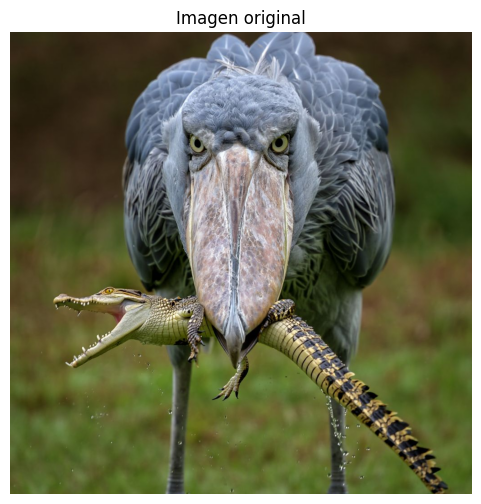

In [13]:
img = cv2.imread('data/pajaroMiedoso2.jpg') #El pajaro de "my honest reaction"
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.title("Imagen original")
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## Filtros

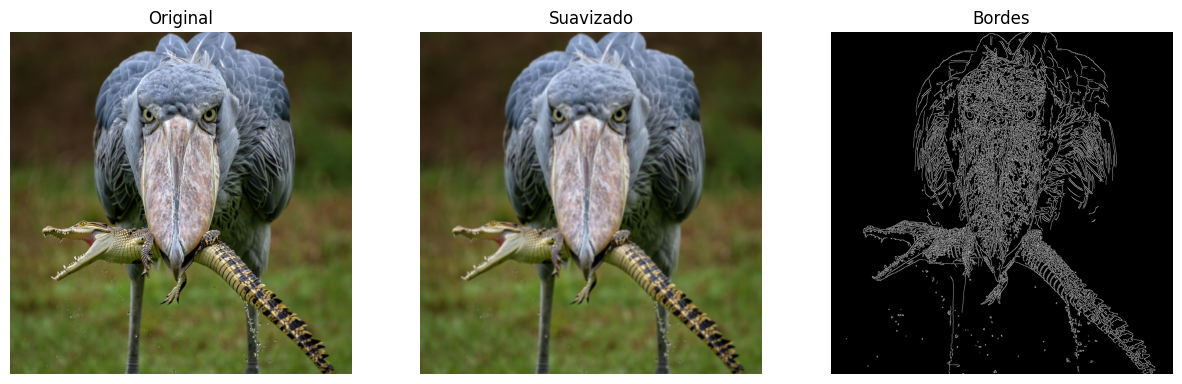

In [14]:
# — Suavizado / desenfoque
blur = cv2.GaussianBlur(img_rgb, (9,9), 0)

# — Detección de bordes
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 60, 150)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title("Original");  plt.imshow(img_rgb); plt.axis('off')
plt.subplot(1,3,2); plt.title("Suavizado"); plt.imshow(blur); plt.axis('off')
plt.subplot(1,3,3); plt.title("Bordes");    plt.imshow(edges, cmap='gray'); plt.axis('off')
plt.show()

## Canales rgb

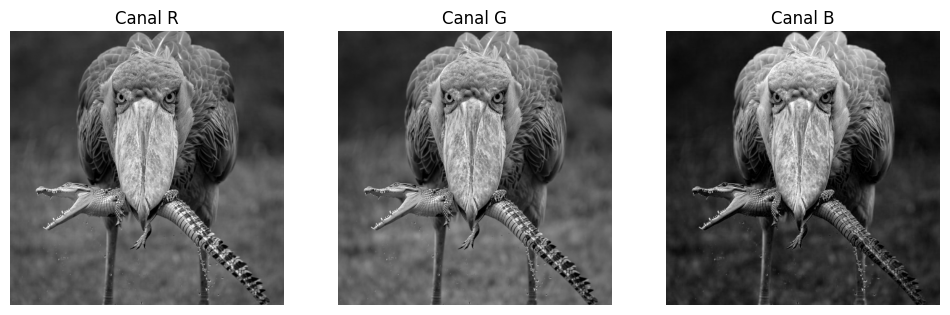

In [15]:
r,g,b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Canal R"); plt.imshow(r, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Canal G"); plt.imshow(g, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Canal B"); plt.imshow(b, cmap='gray'); plt.axis('off')
plt.show()

## Morfologia

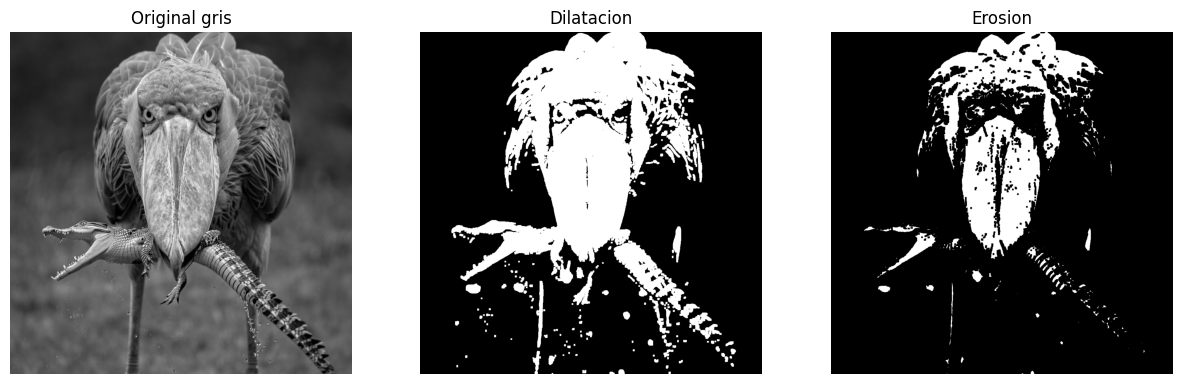

In [16]:
kernel = np.ones((5,5), np.uint8)
gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
ret,thresh = cv2.threshold(gray_img,120,255,cv2.THRESH_BINARY)

# — Dilatación
dilate = cv2.dilate(thresh, kernel, 3)

# — Erosión
erode = cv2.erode(thresh, kernel, 3)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title("Original gris"); plt.imshow(gray_img,cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Dilatacion");   plt.imshow(dilate,cmap='gray');  plt.axis('off')
plt.subplot(1,3,3); plt.title("Erosion");     plt.imshow(erode,cmap='gray');    plt.axis('off')  #que miedo que da asi
plt.show()

## Generar el GIF

In [ ]:

def to_rgb(img):   # Hace todas las imagenes iguales
    if len(img.shape) == 2:  # Si es escala de grises
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    if img.shape[2] == 1:    # Si es una sola capa
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img  # Si ya es RGB → no toca


framesfiltros = [to_rgb(img_rgb), to_rgb(blur), to_rgb(edges)]
framesmorfologia = [to_rgb(gray_img), to_rgb(dilate), to_rgb(erode)]
framescompletos = [to_rgb(img_rgb), to_rgb(blur), to_rgb(edges), to_rgb(dilate), to_rgb(erode)]

#Procuré que le duracion de cada frame fuera larga pero creo que no se vio reflejado en los gifs
imageio.mimsave(
    "gifs/filtros.gif",
    framesfiltros,
    format="GIF",
    duration=[2.0] * len(framesfiltros), 
    loop=0  
)
imageio.mimsave(
    "gifs/morfologia.gif",
    framesmorfologia,
    format="GIF",
    duration=[2.0] * len(framesmorfologia),
    loop=0
)

imageio.mimsave(
    "gifs/proceso.gif",
    framescompletos,
    format="GIF",
    duration=[2.0] * len(framescompletos),
    loop=0
)


print("GIF generados en la carpeta python/gifs")

GIF generados en la carpeta python/gifs
